Languages: (77, 6), Forms: (82888, 6)
inventorySize: Min=Western Farsi (29.000), Max=Lithuanian (86.000)
avgLength: Min=English (4.240), Max=Slovene (6.749)
avgCluster: Min=Chuvash (1.255), Max=Lithuanian (2.696)
avgVowRatio: Min=Russian (0.388), Max=Northern Pashto (1.302)


<Figure size 1200x1000 with 0 Axes>

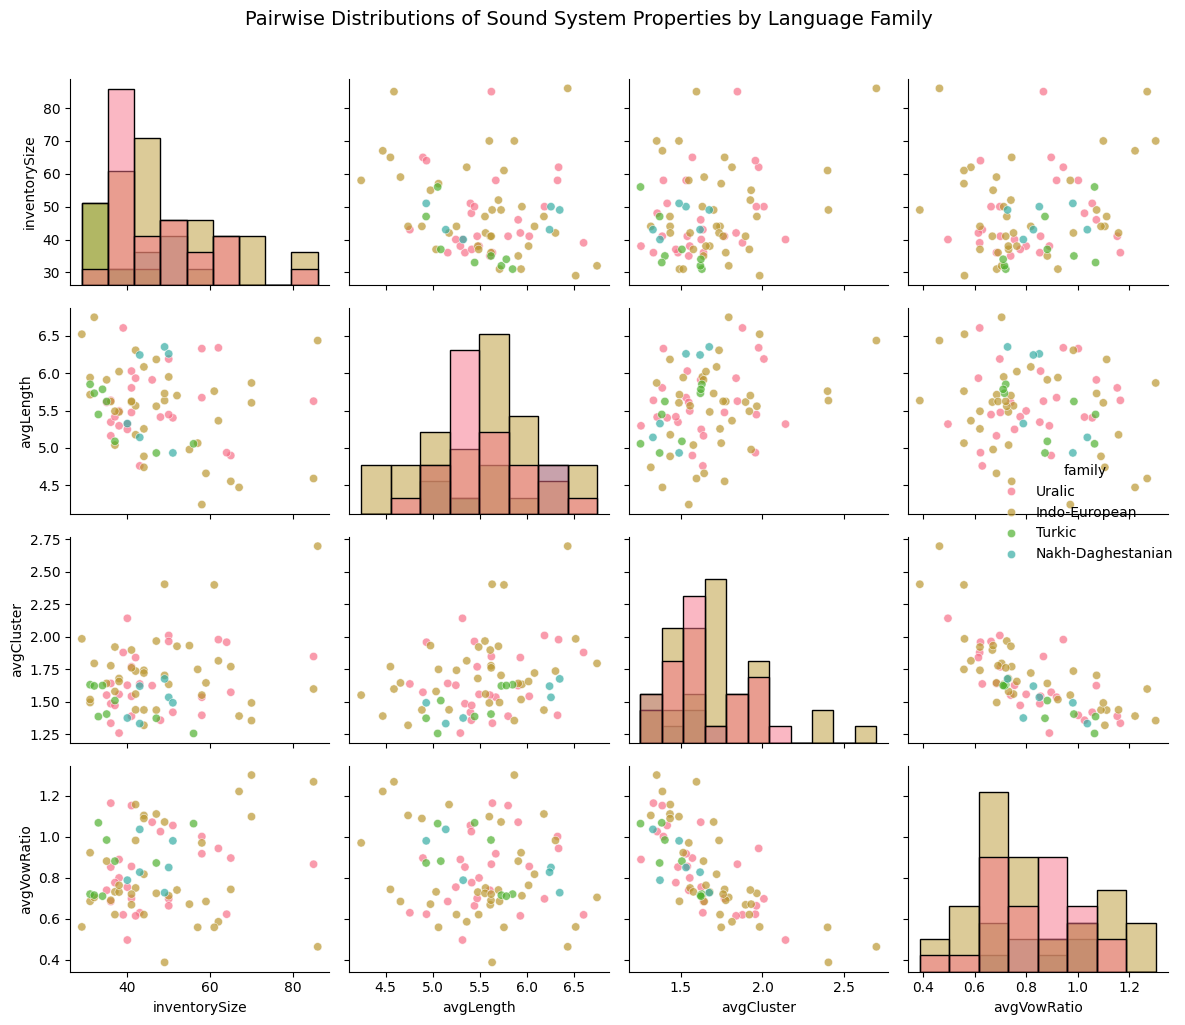


Correlation matrix:
               inventorySize  avgLength  avgCluster  avgVowRatio
inventorySize          1.000     -0.221       0.253        0.172
avgLength             -0.221      1.000       0.291       -0.178
avgCluster             0.253      0.291       1.000       -0.725
avgVowRatio            0.172     -0.178      -0.725        1.000

Research Question: Do sound inventory sizes differ between language families?
Appropriate test: One-way ANOVA (Analysis of Variance)
ANOVA data: 77 observations
Levene's test: F=1.3863, p=0.2538
ANOVA Results:
                 sum_sq    df         F    PR(>F)
C(family)    800.698292   3.0  1.675251  0.179785
Residual   11630.288721  73.0       NaN       NaN
No significant differences (p=0.1798 >= 0.05)
Modeling data: 77 observations
inventorySize: R²=0.0490, AIC=121.05
avgCluster: R²=0.0845, AIC=118.13
avgVowRatio: R²=0.0316, AIC=122.45
inventorySize + avgCluster: R²=0.1774, AIC=111.89
inventorySize + avgVowRatio: R²=0.0691, AIC=121.41
avgCluste

In [1]:
# Cell 1: Import Libraries and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

# Cell 2: Task 1a - Load Data
try:
    languages_df = pd.read_csv('languages.tsv', sep='\t')
    forms_df = pd.read_csv('forms.tsv', sep='\t')
    print(f"Languages: {languages_df.shape}, Forms: {forms_df.shape}")
except FileNotFoundError as e:
    print(f"Error: {e}")

# Cell 3: Task 1b - Aggregate and Merge Data
forms_agg = forms_df.groupby('isocode').agg({
    'wordLength': 'mean',
    'longestClusterLength': 'mean',
    'vowConsRatio': 'mean'
}).round(3)

forms_agg.columns = ['avgLength', 'avgCluster', 'avgVowRatio']
forms_agg.reset_index(inplace=True)

main_df = languages_df.merge(forms_agg, on='isocode', how='left')

# Cell 4: Task 1c - Find Min/Max Values
numerical_vars = ['inventorySize', 'avgLength', 'avgCluster', 'avgVowRatio']

for var in numerical_vars:
    if var in main_df.columns:
        min_idx = main_df[var].idxmin()
        max_idx = main_df[var].idxmax()
        print(f"{var}: Min={main_df.loc[min_idx, 'name']} ({main_df.loc[min_idx, var]:.3f}), Max={main_df.loc[max_idx, 'name']} ({main_df.loc[max_idx, var]:.3f})")

# Cell 5: Task 1d - Create Pairplot
plt.figure(figsize=(12, 10))
if all(col in main_df.columns for col in numerical_vars):
    plot_data = main_df[numerical_vars + ['family']].copy()
    g = sns.pairplot(plot_data, hue='family', diag_kind='hist', plot_kws={'alpha': 0.7})
    g.fig.suptitle('Pairwise Distributions of Sound System Properties by Language Family', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    corr_matrix = main_df[numerical_vars].corr()
    print("\nCorrelation matrix:")
    print(corr_matrix.round(3))

# Cell 6: Task 2a - Choose Statistical Test
print("\nResearch Question: Do sound inventory sizes differ between language families?")
print("Appropriate test: One-way ANOVA (Analysis of Variance)")

# Cell 7: Task 2b - Check ANOVA Assumptions
anova_data = main_df[['inventorySize', 'family']].dropna()
print(f"ANOVA data: {anova_data.shape[0]} observations")

# Check homogeneity of variances (Levene's test)
family_groups = [group['inventorySize'].values for name, group in anova_data.groupby('family')]
levene_stat, levene_p = stats.levene(*family_groups)
print(f"Levene's test: F={levene_stat:.4f}, p={levene_p:.4f}")

# Cell 8: Task 2c - Perform ANOVA
model = ols('inventorySize ~ C(family)', data=anova_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Results:")
print(anova_table)

f_stat = anova_table.loc['C(family)', 'F']
p_value = anova_table.loc['C(family)', 'PR(>F)']
alpha = 0.05

if p_value < alpha:
    print(f"Significant differences found (p={p_value:.4f} < {alpha})")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(endog=anova_data['inventorySize'], groups=anova_data['family'], alpha=0.05)
        print(tukey)
    except:
        pass
else:
    print(f"No significant differences (p={p_value:.4f} >= {alpha})")

# Cell 9: Task 3 - Linear Regression Models Setup
X_vars = ['inventorySize', 'avgCluster', 'avgVowRatio']
y_var = 'avgLength'
model_data = main_df[X_vars + [y_var]].dropna()

print(f"Modeling data: {model_data.shape[0]} observations")

# Cell 10: Task 3 - Single Predictor Models
single_models = {}
for predictor in X_vars:
    X = sm.add_constant(model_data[predictor])
    y = model_data[y_var]
    model = sm.OLS(y, X).fit()
    single_models[predictor] = model
    print(f"{predictor}: R²={model.rsquared:.4f}, AIC={model.aic:.2f}")

# Cell 11: Task 3 - Two Predictor Models
two_models = {}
for pred_pair in combinations(X_vars, 2):
    model_name = ' + '.join(pred_pair)
    X = sm.add_constant(model_data[list(pred_pair)])
    y = model_data[y_var]
    model = sm.OLS(y, X).fit()
    two_models[model_name] = model
    print(f"{model_name}: R²={model.rsquared:.4f}, AIC={model.aic:.2f}")

# Cell 12: Task 3 - Three Predictor Model and Best Model Selection
X = sm.add_constant(model_data[X_vars])
y = model_data[y_var]
full_model = sm.OLS(y, X).fit()
print(f"Full model: R²={full_model.rsquared:.4f}, AIC={full_model.aic:.2f}")

# Find best model based on adjusted R²
all_models = {**single_models, **two_models, 'Full Model': full_model}
best_model_name = max(all_models.keys(), key=lambda k: all_models[k].rsquared_adj)
best_model = all_models[best_model_name]

print(f"\nBest model: {best_model_name} (Adj R²={best_model.rsquared_adj:.4f})")

# Determine predictors for sklearn comparison
if best_model_name == 'Full Model':
    best_predictors = X_vars
elif '+' in best_model_name:
    best_predictors = best_model_name.split(' + ')
else:
    best_predictors = [best_model_name]

# Cell 13: Task 4 - Scikit-learn Model Comparison
X = model_data[best_predictors]
y = model_data['avgLength']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cell 14: Task 4 - Fit Different Models
# Regular Linear Regression
lr = LinearRegression().fit(X, y)
lr_r2 = lr.score(X, y)

# Lasso Regression - find best alpha
alphas = [0.001, 0.01, 0.1, 1.0]
best_lasso_alpha = 0.1
for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=2000).fit(X_scaled, y)
    if lasso_temp.score(X_scaled, y) > best_lasso_alpha:
        best_lasso_alpha = alpha

lasso = Lasso(alpha=best_lasso_alpha, max_iter=2000).fit(X_scaled, y)
elastic = ElasticNet(alpha=best_lasso_alpha, l1_ratio=0.5, max_iter=2000).fit(X_scaled, y)

print(f"Model Performance:")
print(f"Linear: {lr.score(X, y):.4f}")
print(f"Lasso: {lasso.score(X_scaled, y):.4f}")
print(f"ElasticNet: {elastic.score(X_scaled, y):.4f}")

# Cell 15: Task 5 - Logistic Regression for Vowel Length
target_col = None
if 'phonVowLength' in main_df.columns:
    target_col = 'phonVowLength'
else:
    possible_cols = [col for col in main_df.columns if 'vowel' in col.lower() and 'length' in col.lower()]
    if possible_cols:
        target_col = possible_cols[0]

if target_col:
    # Convert to binary
    if main_df[target_col].dtype == 'object':
        main_df['vowel_length_binary'] = main_df[target_col].map({
            'True': 1, 'true': 1, 'TRUE': 1, 'T': 1,
            'False': 0, 'false': 0, 'FALSE': 0, 'F': 0
        })
    elif main_df[target_col].dtype == 'bool':
        main_df['vowel_length_binary'] = main_df[target_col].astype(int)
    else:
        main_df['vowel_length_binary'] = main_df[target_col]
    
    # Choose predictors for vowel length distinction
    potential_predictors = ['inventorySize', 'avgLength', 'avgCluster', 'avgVowRatio']
    available_predictors = [col for col in potential_predictors if col in main_df.columns]
    
    modeling_cols = available_predictors + ['vowel_length_binary']
    logistic_data = main_df[modeling_cols].dropna()
    
    # Cell 17: Task 5b - Fit Logistic Regression
    
    if len(logistic_data) > 0 and len(logistic_data['vowel_length_binary'].unique()) >= 2:
        X_log = logistic_data[available_predictors]
        y_log = logistic_data['vowel_length_binary']
        
        scaler_log = StandardScaler()
        X_log_scaled = scaler_log.fit_transform(X_log)
        
        # Fit logistic regression
        log_reg = LogisticRegression(random_state=42, max_iter=1000).fit(X_log_scaled, y_log)
        y_pred = log_reg.predict(X_log_scaled)
        accuracy = accuracy_score(y_log, y_pred)
        
        print(f"Logistic Regression:")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Baseline: {max(y_log.mean(), 1 - y_log.mean()):.3f}")
        
        # Cell 18: Task 5c - Cross-validation and Final Analysis
        # Cross-validation
        cv_scores = cross_val_score(log_reg, X_log_scaled, y_log, cv=5, scoring='accuracy')
        print(f"CV accuracy: {cv_scores.mean():.3f} (±{cv_scores.std() * 2:.3f})")
        
        # Feature importance
        for i, feature in enumerate(available_predictors):
            print(f"{feature}: {log_reg.coef_[0][i]:.4f}")

print("Analysis completed!")